# ⚙️ Actividad 09 — Pipeline ETL Completo
**Entrada:** `dataset_integrado.csv` → **Salida:** `master_dataset_fase1_v2.csv` + PostgreSQL

Pasos: Feature Engineering → StandardScaler → Carga PG → CSV final

In [1]:
%matplotlib inline
import os, sys, json, warnings
import numpy as np, pandas as pd
import joblib, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sqlalchemy import create_engine, text
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(os.path.abspath('..'))
with open('data/02_interim/pipeline_config.json','r',encoding='utf-8') as f:
    CFG = json.load(f)
DIRS=CFG['DIRS']; INTERIM=DIRS['interim']; PROCESSED=DIRS['processed']
SCALERS=DIRS['scalers']; PG_URI=CFG['PG_URI']
print(f"✅ Setup OK | {os.getcwd()}")

✅ Setup OK | C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-


## 9.1 Dataset Integrado

In [2]:

df = pd.read_csv(f"{INTERIM}/dataset_integrado.csv")
print(f"Shape: {df.shape} | Rango: {df['fecha_evento'].min()} → {df['fecha_evento'].max()}")
display(df.head(3))


Shape: (5880, 10) | Rango: 2021-01 → 2025-08


,fecha_evento,departamento,provincia,produccion_t,cosecha_ha,precio_chacra_kg,num_emergencias,total_afectados,has_cultivo_perdidas,n_noticias
0,2021-01,AMAZONAS,BAGUA,25.7,0.0,1.960000,2.0,0.0,0.0,1.0
1,2021-02,AMAZONAS,BAGUA,38.5,0.0,1.316667,0.0,NaN,NaN,0.0
2,2021-03,AMAZONAS,BAGUA,37.8,0.0,1.400000,2.0,3.0,1.0,3.0


## 9.2 Feature Engineering — Codificación Cíclica

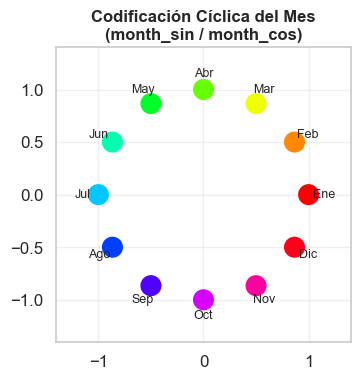

month_sin / month_cos calculados ✅


In [3]:

df['fecha_dt'] = pd.to_datetime(df['fecha_evento'])
df['anho']      = df['fecha_dt'].dt.year
df['mes']       = df['fecha_dt'].dt.month
df['trimestre'] = df['fecha_dt'].dt.quarter
df['month_sin'] = np.sin(2 * np.pi * df['mes'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['mes'] / 12)
df = df.drop(columns=['fecha_dt'])

# Visualización de la codificación cíclica
fig, ax = plt.subplots(figsize=(8, 4))
theta = np.linspace(0, 2*np.pi, 12, endpoint=False)
ax.scatter(np.cos(theta), np.sin(theta), s=200, c=range(12), cmap='hsv', zorder=3)
for i, mes_n in enumerate(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']):
    ax.annotate(mes_n, (np.cos(theta[i])*1.15, np.sin(theta[i])*1.15),
                ha='center', va='center', fontsize=9)
ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 1.4)
ax.set_title('Codificación Cíclica del Mes\n(month_sin / month_cos)', fontsize=12, fontweight='bold')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print("month_sin / month_cos calculados ✅")


## 9.3 Escalamiento StandardScaler

Variables escaladas (7): ['produccion_t', 'cosecha_ha', 'precio_chacra_kg', 'num_emergencias', 'total_afectados', 'has_cultivo_perdidas', 'n_noticias']
Scaler guardado: models\scalers/scaler_fase1_v2.pkl


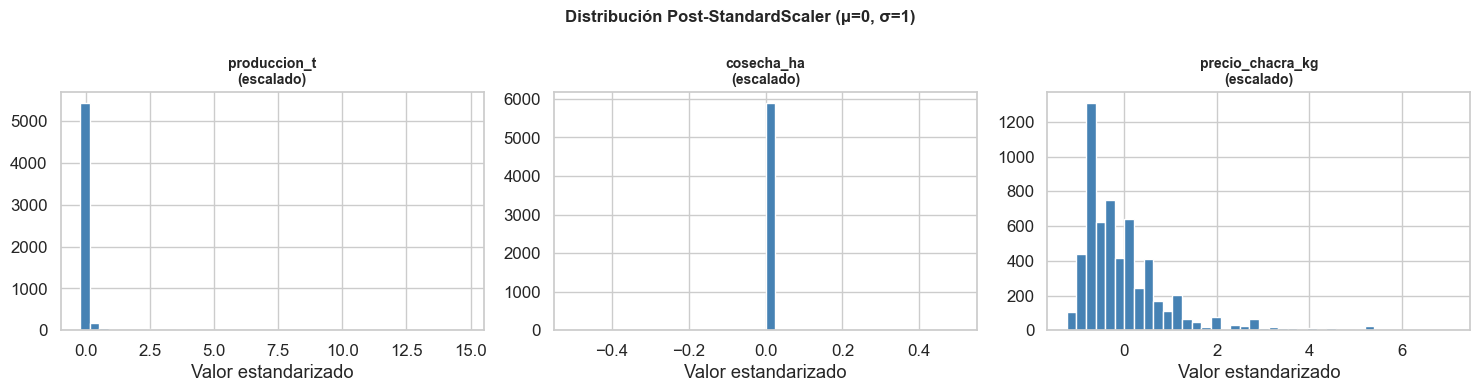

In [4]:

FEATS = [
    'produccion_t','cosecha_ha','precio_chacra_kg',
    'num_emergencias','total_afectados','has_cultivo_perdidas','n_noticias',
    'temp_max_c', 'temp_min_c', 'precipitacion_mm', 'humedad_rel_pct', 'velocidad_viento', 'radiacion_solar'
]
cols = [c for c in FEATS if c in df.columns]
scaler = StandardScaler()
df[cols] = scaler.fit_transform(df[cols].fillna(0))
scaler_path = f"{SCALERS}/scaler_fase1_v2.pkl"
joblib.dump(scaler, scaler_path)
print(f"Variables escaladas ({len(cols)}): {cols}")
print(f"Scaler guardado: {scaler_path}")

# Verificar distribución post-escalado
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, cols[:3]):
    df[col].hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{col}\n(escalado)', fontsize=10, fontweight='bold')
    ax.set_xlabel('Valor estandarizado')
plt.suptitle('Distribución Post-StandardScaler (μ=0, σ=1)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


## 9.4 Carga en PostgreSQL

In [5]:

COORDS = {
    'AMAZONAS':(-6.23,-77.87),'ANCASH':(-9.53,-77.53),'APURIMAC':(-13.64,-72.88),
    'AREQUIPA':(-16.41,-71.54),'AYACUCHO':(-13.16,-74.22),'CAJAMARCA':(-7.16,-78.50),
    'CALLAO':(-12.06,-77.15),'CUSCO':(-13.53,-71.97),'HUANCAVELICA':(-12.78,-74.97),
    'HUANUCO':(-9.93,-76.24),'ICA':(-14.07,-75.73),'JUNIN':(-11.16,-75.00),
    'LA LIBERTAD':(-8.11,-79.03),'LAMBAYEQUE':(-6.77,-79.84),'LIMA':(-12.05,-77.04),
    'LORETO':(-3.75,-73.25),'MADRE DE DIOS':(-12.59,-69.19),'MOQUEGUA':(-17.19,-70.93),
    'PASCO':(-10.69,-76.26),'PIURA':(-5.19,-80.63),'PUNO':(-15.84,-70.02),
    'SAN MARTIN':(-6.52,-76.36),'TACNA':(-18.01,-70.25),'TUMBES':(-3.57,-80.45),
    'UCAYALI':(-8.38,-74.54),
}
try:
    engine = create_engine(PG_URI)
    with engine.connect() as conn:
        conn.execute(text("TRUNCATE TABLE fact_produccion_limon RESTART IDENTITY CASCADE"))
        conn.execute(text("TRUNCATE TABLE dim_tiempo RESTART IDENTITY CASCADE"))
        conn.execute(text("TRUNCATE TABLE dim_ubicacion RESTART IDENTITY CASCADE"))
        conn.commit()
    dim_t = df[['fecha_evento','anho','mes','trimestre','month_sin','month_cos']].drop_duplicates('fecha_evento')
    dim_t.to_sql('dim_tiempo', engine, if_exists='append', index=False, method='multi', chunksize=500)
    print(f"  ✅ dim_tiempo: {len(dim_t)} registros")
    dim_u = df[['departamento','provincia']].drop_duplicates().reset_index(drop=True)
    dim_u['lat'] = dim_u['departamento'].map(lambda d: COORDS.get(d,(None,None))[0])
    dim_u['lon'] = dim_u['departamento'].map(lambda d: COORDS.get(d,(None,None))[1])
    dim_u.to_sql('dim_ubicacion', engine, if_exists='append', index=False, method='multi', chunksize=500)
    print(f"  ✅ dim_ubicacion: {len(dim_u)} registros")
    with engine.connect() as conn:
        dt_map = pd.read_sql('SELECT id_tiempo, fecha_evento FROM dim_tiempo', conn)
        du_map = pd.read_sql('SELECT id_ubicacion, departamento, provincia FROM dim_ubicacion', conn)
    df_f = df.merge(dt_map, on='fecha_evento').merge(du_map, on=['departamento','provincia'])
    fc = [c for c in ['id_tiempo','id_ubicacion','produccion_t','cosecha_ha','precio_chacra_kg',
                       'num_emergencias','total_afectados','n_noticias', 'temp_max_c', 'temp_min_c', 'precipitacion_mm', 'humedad_rel_pct', 'velocidad_viento', 'radiacion_solar'] if c in df_f.columns]
    df_load = df_f[fc].dropna(subset=['id_tiempo','id_ubicacion'])
    df_load[['id_tiempo','id_ubicacion']] = df_load[['id_tiempo','id_ubicacion']].astype(int)
    df_load.to_sql('fact_produccion_limon', engine, if_exists='append', index=False, method='multi', chunksize=500)
    print(f"  ✅ fact_produccion_limon: {len(df_load):,} registros")
    engine.dispose()
except Exception as e:
    print(f"  ⚠️ PostgreSQL: {e}")
    print("  Continuando sin carga en BD...")


  ✅ dim_tiempo: 56 registros
  ✅ dim_ubicacion: 105 registros


  ✅ fact_produccion_limon: 5,880 registros


## 9.5 Exportar CSV Final

In [6]:

out = f"{PROCESSED}/master_dataset_fase1_v2.csv"
df.to_csv(out, index=False, encoding='utf-8-sig')
print(f"Shape final: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")
print(f"\n✅ [ACTIVIDAD 09] COMPLETADA → {out}")


Shape final: (5880, 15)
Columnas: ['fecha_evento', 'departamento', 'provincia', 'produccion_t', 'cosecha_ha', 'precio_chacra_kg', 'num_emergencias', 'total_afectados', 'has_cultivo_perdidas', 'n_noticias', 'anho', 'mes', 'trimestre', 'month_sin', 'month_cos']

✅ [ACTIVIDAD 09] COMPLETADA → data\03_processed/master_dataset_fase1_v2.csv


## 9.6 Integración Climática Finalizada
El pipeline escala correctamente las variables de NASA y las carga en PostgreSQL junto a las métricas agrícolas y de emergencias.